# **EfficientNet Pre-trained Binary Model with Raw Input**

In this notebook we test a pre-trained EfficientNet model to predict Animal vs Non-animal. For this, the original images were used.

## Libraries

In [1]:
# Libraries
import pandas as pd

from deep.constants import METADATA_FILE, ROOT, SEED
from deep.models.model_runs import run_binary_model
from deep.models.model_defs import efficient_net

2025-04-27 00:47:18.663564: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-27 00:47:18.674914: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-27 00:47:18.689739: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-27 00:47:18.694332: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-27 00:47:18.704346: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Setting options
pd.set_option('display.max_rows', None)

## Data Loading

In [3]:
# Load the metadata
data = pd.read_csv(METADATA_FILE)

# Drop unnecessary columns for this problem
data.drop(columns=['phylum', 'family'], inplace=True)

## Data Preprocessing and Modelling

In [4]:
# Define path
binary_baseline_path = f"{ROOT}/models/binary_scores.json"

### Raw Model

In this section we test which loss function yelds the best results

#### Binary CrossEntropy

2025-04-27 00:47:20.573894: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-04-27 00:47:20.573930: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:135] retrieving CUDA diagnostic information for host: shadybea
2025-04-27 00:47:20.573935: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:142] hostname: shadybea
2025-04-27 00:47:20.574107: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:166] libcuda reported version is: 550.120.0
2025-04-27 00:47:20.574129: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] kernel reported version is: 550.120.0
2025-04-27 00:47:20.574134: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:249] kernel version seems to match DSO: 550.120.0


No baseline score found, saving current as baseline after run.
Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


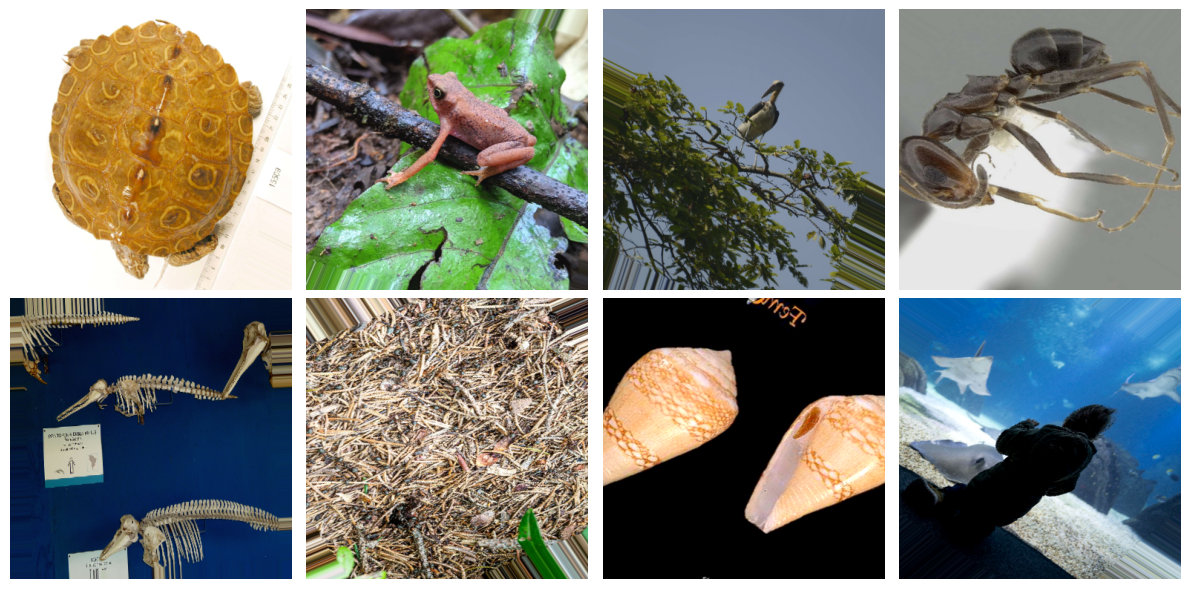

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 48/128 ━━━━━━━━━━━━━━━━━━━━ 12:10 9s/step - accuracy: 0.6994 - auc: 0.5058 - loss: 0.6807 - precision: 0.9312 - recall: 0.7322

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


128/128 ━━━━━━━━━━━━━━━━━━━━ 1381s 11s/step - accuracy: 0.8030 - auc: 0.5088 - loss: 0.5625 - precision: 0.9295 - recall: 0.8534 - val_accuracy: 0.9291 - val_auc: 0.5302 - val_loss: 0.3307 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1360s 11s/step - accuracy: 0.9288 - auc: 0.5102 - loss: 0.2601 - precision: 0.9289 - recall: 0.9999 - val_accuracy: 0.9291 - val_auc: 0.5482 - val_loss: 0.2592 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1358s 11s/step - accuracy: 0.9311 - auc: 0.5175 - loss: 0.2502 - precision: 0.9311 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc: 0.5716 - val_loss: 0.2546 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1354s 11s/step - accuracy: 0.9285 - auc: 0.5464 - loss: 0.2568 - precision: 0.9285 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc: 0.6136 - val_loss: 0.2549 - va

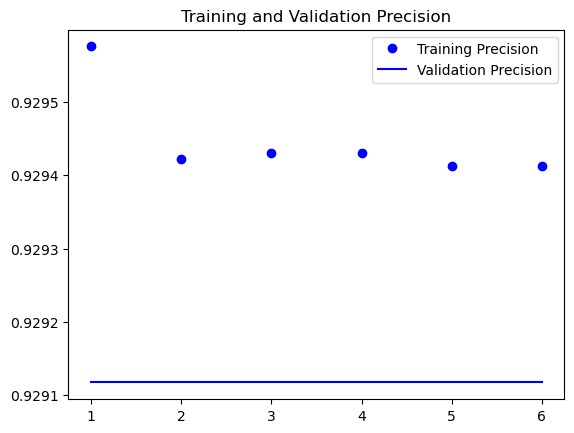

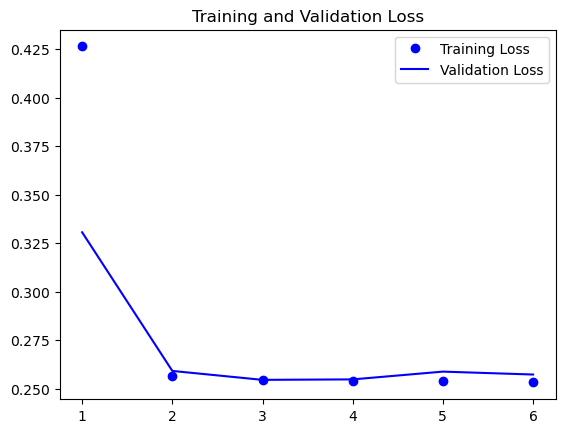

Saved current model as new baseline


In [5]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEED
    ,model=efficient_net(
        regularizer=False
        ,dropout=False
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='original'
)

#### Focal Loss

Loaded baseline score: 0.9291174411773682
Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


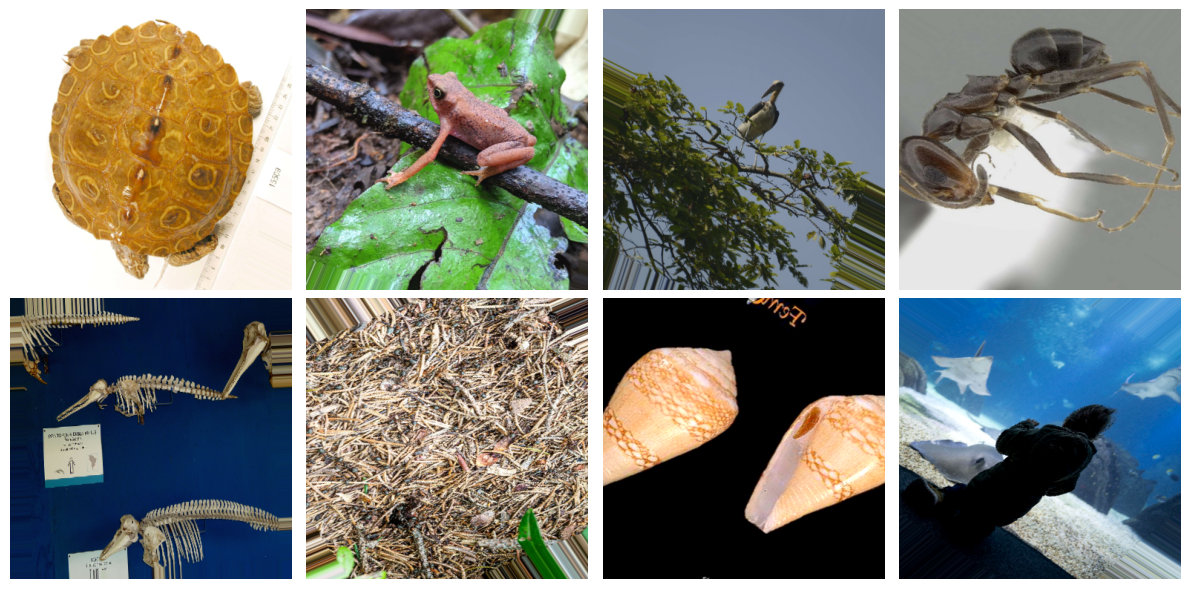

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 72/128 ━━━━━━━━━━━━━━━━━━━━ 8:36 9s/step - accuracy: 0.8071 - auc_1: 0.4756 - loss: 0.0096 - precision: 0.9295 - recall: 0.8586

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


128/128 ━━━━━━━━━━━━━━━━━━━━ 1393s 11s/step - accuracy: 0.8473 - auc_1: 0.4873 - loss: 0.0084 - precision: 0.9289 - recall: 0.9056 - val_accuracy: 0.9291 - val_auc_1: 0.4653 - val_loss: 0.0059 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1366s 11s/step - accuracy: 0.9310 - auc_1: 0.5197 - loss: 0.0058 - precision: 0.9311 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc_1: 0.4826 - val_loss: 0.0059 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9299 - auc_1: 0.4924 - loss: 0.0059 - precision: 0.9299 - recall: 1.0000
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
128/128 ━━━━━━━━━━━━━━━━━━━━ 1367s 11s/step - accuracy: 0.9299 - auc_1: 0.4924 - loss: 0.0059 - precision: 0.9299 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc_1: 0.5042 - val_loss: 0.0059 - val_precision: 0.9291 - val_recall: 1.0000 - learning_ra

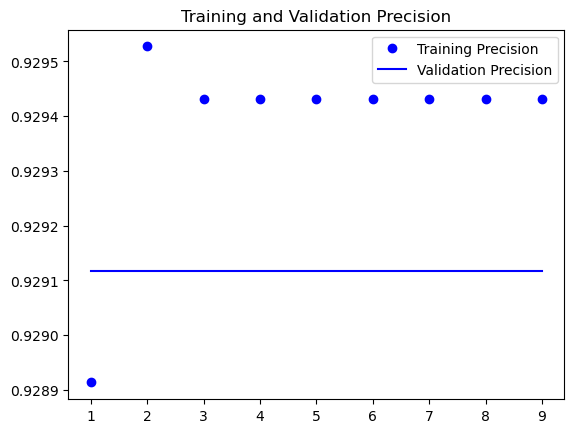

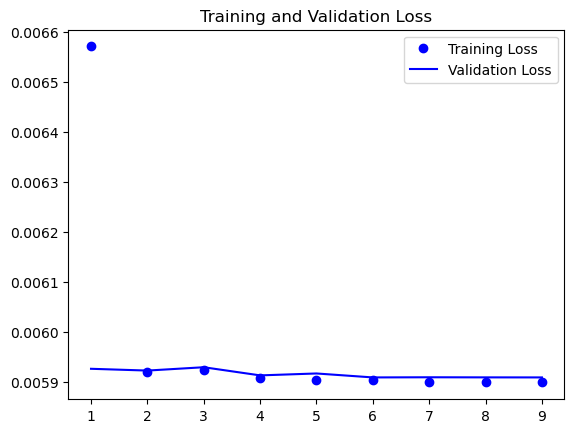

Current model not better than baseline


In [6]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEED
    ,model=efficient_net(
        regularizer=False
        ,dropout=False
    )
    ,loss='focal'
    ,epochs=10
    ,type='original'
)

The binary crossentropy loss function performed better and so this is the loss function we will be using from now on.

### Model with Regularization

In this section we add L2 regularization to our model and test if it improves the model

Loaded baseline score: 0.9291174411773682
Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


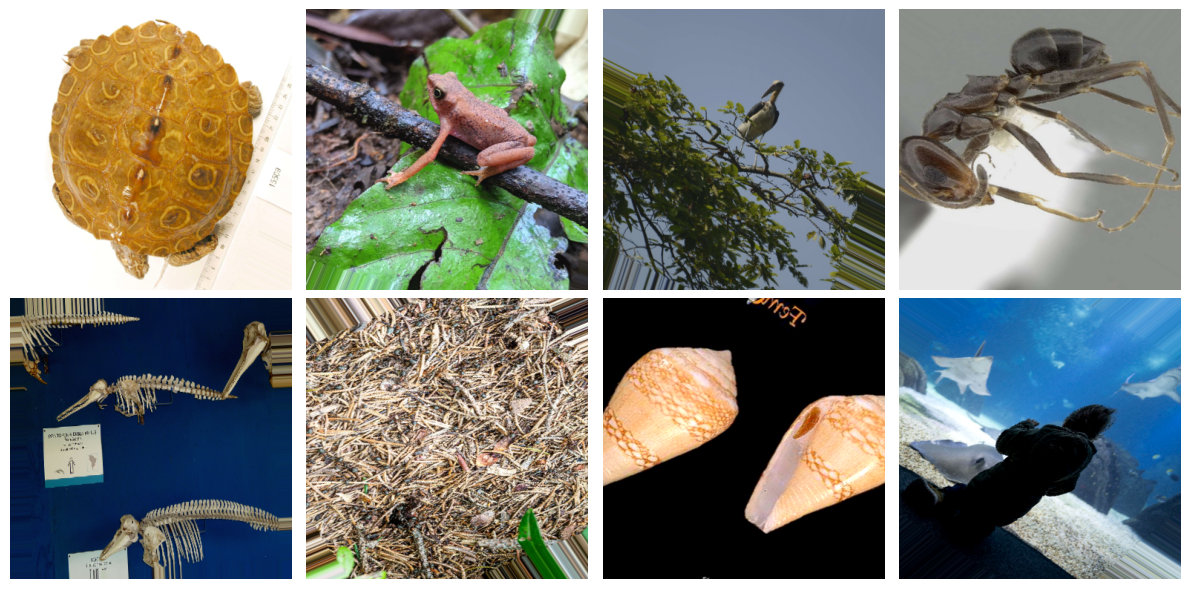

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
110/128 ━━━━━━━━━━━━━━━━━━━━ 2:42 9s/step - accuracy: 0.8334 - auc_2: 0.5091 - loss: 0.6522 - precision: 0.9295 - recall: 0.8894

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


128/128 ━━━━━━━━━━━━━━━━━━━━ 1356s 10s/step - accuracy: 0.8440 - auc_2: 0.5092 - loss: 0.6297 - precision: 0.9295 - recall: 0.9015 - val_accuracy: 0.9291 - val_auc_2: 0.5222 - val_loss: 0.3027 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1336s 10s/step - accuracy: 0.9277 - auc_2: 0.5404 - loss: 0.2863 - precision: 0.9277 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc_2: 0.5170 - val_loss: 0.3760 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1334s 10s/step - accuracy: 0.9255 - auc_2: 0.5178 - loss: 0.2726 - precision: 0.9255 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc_2: 0.5487 - val_loss: 0.2765 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1333s 10s/step - accuracy: 0.9290 - auc_2: 0.5294 - loss: 0.2590 - precision: 0.9291 - recall: 0.9999 - val_accuracy: 0.9291 - val_auc_2: 0.5610 - val_l

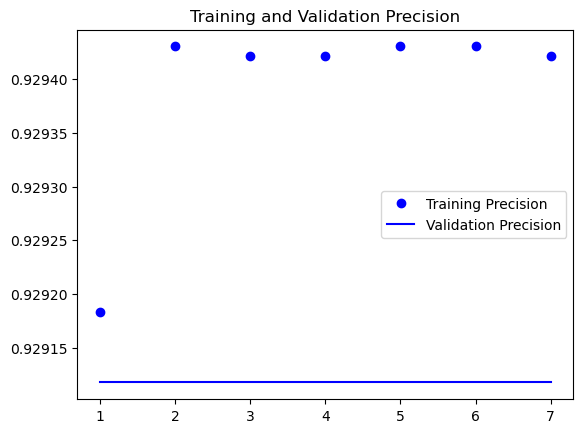

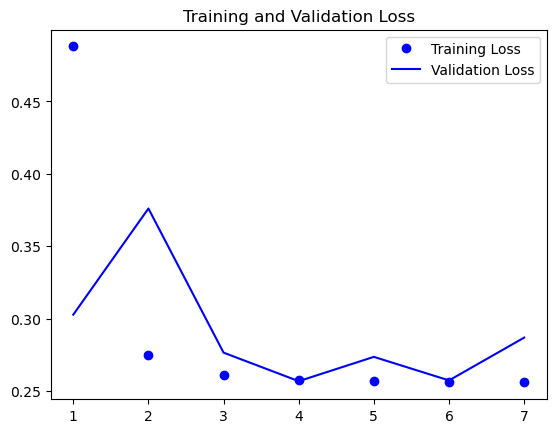

Current model not better than baseline


In [7]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEED
    ,model=efficient_net(
        regularizer=True
        ,dropout=False
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='original'
)

Regularization did not improve the model.

### Model with Dropout

In this section we add a dropout layer to the model and test if it improves the results.

Loaded baseline score: 0.9291174411773682
Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


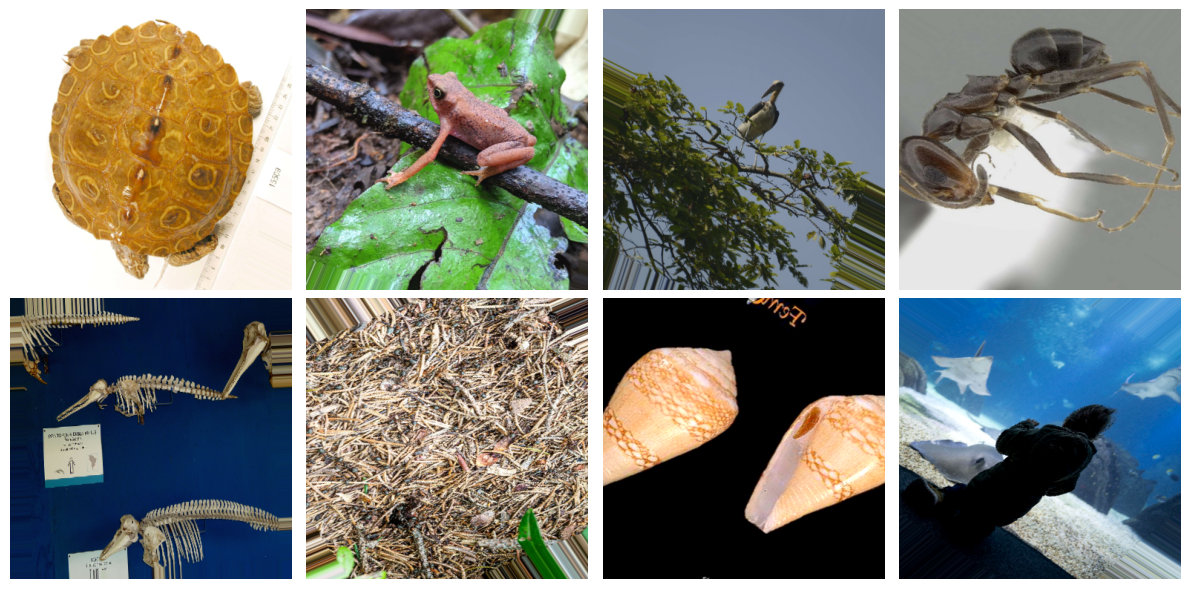

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 11/128 ━━━━━━━━━━━━━━━━━━━━ 16:44 9s/step - accuracy: 0.5605 - auc_3: 0.4949 - loss: 0.8696 - precision: 0.9273 - recall: 0.5682

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


128/128 ━━━━━━━━━━━━━━━━━━━━ 1382s 11s/step - accuracy: 0.7226 - auc_3: 0.4997 - loss: 0.6230 - precision: 0.9307 - recall: 0.7579 - val_accuracy: 0.9284 - val_auc_3: 0.5123 - val_loss: 0.6417 - val_precision: 0.9303 - val_recall: 0.9978 - learning_rate: 0.0010
Epoch 2/10
106/128 ━━━━━━━━━━━━━━━━━━━━ 3:21 9s/step - accuracy: 0.9219 - auc_3: 0.4830 - loss: 0.3017 - precision: 0.9282 - recall: 0.9927

In [ ]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEED
    ,model=efficient_net(
        regularizer=False
        ,dropout=True
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='original'
)

The dropout layer did not improve the model.

Now, we will attempt to transform the input images and recheck the model.